# Mixed species model simulations

Run mixed species model simulations of many trials, with the same model parameter set but varying initial conditions. Batch simulations like this are required to get a good estimate of the steady-state distributions; since the final-state of single simulations will often depend on the initial condition.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from joblib import Parallel, delayed
from tqdm.notebook import tqdm, trange
from scipy.spatial import Delaunay
from scipy.sparse.csgraph import connected_components
from scipy.stats import mode
from spatialmodels import MixedSpeciesModel
import seaborn as sns
import os

In [6]:
#set working directory

os.chdir('/Users/jahanvitiwari/mixedspecies/simulation data')  #add working directory
print(os.getcwd())

/Users/jahanvitiwari/mixedspecies/simulation data


In [7]:
rng = np.random.default_rng()

In [7]:
# Set up the model parameters -- The two values in bracket refers to the model parameters for the two species in mixed species model. 
# Set same value for all parameters for both species to generate null model. 

v0 = (8, 8)     # Preferred swimming speed
mu_0 = (1, 1)   # Strength of relaxation to preferred speed

mu_v = (1, 6)   # Strength of speed matching
mu_al = (5, 5)  # Strength of alignment
D = (12, 12)      # Noise strength

r0 = (0.5, 0.5) # Preferred distance/repulsion zone

mu_d = np.array(((2, 1), 
                 (1, 6)))      # Strength of attraction/repulsion

dt = 0.001      # Integration time-step
# (Simulation duration in seconds = T * dt)

model = MixedSpeciesModel(
    v0=v0, D=D, r0=r0, mu_d=mu_d,
    mu_0=mu_0, mu_al=mu_al, mu_v=mu_v, )


nsims = 100    # Number of simulations
T = 25000     # Duration of each simulation
vmax = np.max(v0)
discard = 5000  # Discard these many points at the beginning of the simulation

In [8]:
# Set up and the simulation pipeline that runs many simulations in parallel

def simulate_with_ic(vmax, sigma=np.pi):
    # phi_init = np.linspace(-eta, +eta, NA+NB)
    # e_init = np.column_stack([np.cos(phi_init), np.sin(phi_init)])
    r, v, phi = model.simulate(N=(NA, NB), T=T, dt=dt, 
                               v_init=rng.uniform(0.01, vmax, size = NA + NB), 
                               phi_init=rng.vonmises(0, sigma, size = NA + NB), 
                               r_init=rng.uniform(0, int(2*np.sqrt(NA+NB)), size=(NA + NB, 2)),)
    s = np.mean(v, axis=1)
    e = np.stack((np.cos(phi), np.sin(phi)))  # (2, T, N)
    m = np.mean(e, axis=2)  # (2, T)
    modm = np.linalg.norm(m, axis=0)
    return r, s, m.T, modm

simulate_parallel = delayed(simulate_with_ic)


Run simulations (in parallel) with a range of initial conditions for speed and polarisation.
- **Speed:** Initial velocities of the agents are choosen uniformly between 0 and 1.2 * $v_0$.
- **Polarisation:** Initial orientations are chosen uniformly between $(-\eta, +\eta)$. 

In [9]:
def collect_results(results):
    r_all = np.empty((nsims, T - discard, NA + NB, 2))
    s_all = np.empty((nsims, T - discard))
    m_all = np.empty((nsims, T - discard, 2))
    modm_all = np.empty((nsims, T - discard))


    fig, ax = plt.subplots(2, 2, figsize=(10, 8), layout='constrained')
    for i, (r, s, m, modm) in enumerate(results):
        # colorline(ax[0, 0], modm, s, cmap=plt.get_cmap('hot'), linewidth=1, alpha=0.5)
        # s_all = np.append(s_all, s[discard:])
        # m_all = np.concatenate((m_all, m[discard:, :]), axis=0)
        # modm_all = np.append(modm_all, modm[discard:])
        r_all[i] = r[discard:, ...]
        s_all[i] = s[discard:, ...]
        m_all[i] = m[discard:, ...]
        modm_all[i] = modm[discard:, ...]
        ax[0, 0].plot(modm, s, alpha=0.01, color='k')

    ax[0, 1].hist2d(modm_all.ravel(), s_all.ravel(), bins=100, range=((0, 1), (0, 1.5 * v0[0])))
    ax[0, 0].set(xlim=(0, 1), ylim=(0, 1.5 * v0[0]))

    ax[1, 0].hist(modm_all.ravel(), density=True, bins=100)
    ax[1, 1].hist(s_all.ravel(), density=True, bins=100)

    ax[0, 0].set(xlabel='$m$', ylabel='$v$', title='Simulation Trajectories')
    ax[0, 1].set(xlabel='$m$', ylabel='$v$', title='$(m, v)$ Histogram')
    ax[1, 0].set(xlabel='$m$', ylabel='Density')
    ax[1, 1].set(xlabel='$v$', ylabel='Density')
    # ax[1].set(xlim=(0, 1), ylim=(0, 1.5 * v0))
    # plt.tight_layout()
    plt.show()
    return r_all, s_all, m_all, modm_all

In [10]:
def get_largest_comp(r_all):
    N = NA + NB
    Tskip = 100  # Compute sorting every Tskip frames
    largest_comp_rb = np.empty((nsims, (T - discard) // Tskip))
    largest_comp_tb = np.empty((nsims, (T - discard) // Tskip))

    for i in trange(nsims):
        for t in range(0, T - discard, Tskip):
            tri = Delaunay(r_all[i, t, ...])
            ptr, idx = tri.vertex_neighbor_vertices
            neighbour_matrix = np.zeros((N, N), dtype=bool)
            for j in range(N):
                neighbour_matrix[j, idx[ptr[j]:ptr[j+1]]] = True
        
            neighbour_matrix_rb = neighbour_matrix[:NA, :NA]
            neighbour_matrix_tb = neighbour_matrix[NA:, NA:]
            # print(neighbour_matrix_tb.shape)

            _, comp_rb = connected_components(neighbour_matrix_rb)
            _, comp_tb = connected_components(neighbour_matrix_tb)
            # print(comp_tb)
            # print(mode(comp_tb))
            
            _, largest_comp_rb[i, t // Tskip] = mode(comp_rb)
            _, largest_comp_tb[i, t // Tskip] = mode(comp_tb)
    
    return largest_comp_rb, largest_comp_tb

In [ ]:
# Do all the simulations and collect results

prefix = 'model-with-sorting'

NA, NB = 0, 16
print(f'Running simulations: RB{NA}+TB{NB}')
results = Parallel(n_jobs=-1, verbose=10)(simulate_parallel(vmax=vmax, sigma=np.pi) for _ in range(nsims))
r_all, s_all, m_all, modm_all = collect_results(results)
np.savez(f'{prefix}-rb_{NA}_tb_{NB}.npz', s_all=s_all, m_all=m_all, modm_all=modm_all, r_all=r_all)

NA, NB = 4, 12
print(f'Running simulations: RB{NA}+TB{NB}')
results = Parallel(n_jobs=-1, verbose=10)(simulate_parallel(vmax=vmax, sigma=np.pi) for _ in range(nsims))
r_all, s_all, m_all, modm_all = collect_results(results)
np.savez(f'{prefix}-rb_{NA}_tb_{NB}.npz', s_all=s_all, m_all=m_all, modm_all=modm_all, r_all=r_all)
largest_comp_rb, _ = get_largest_comp(r_all)
sort_rb_4_12 = 100 * np.mean(largest_comp_rb == NA, axis=1)

plt.hist(largest_comp_rb.ravel(), range=(-0.5, NA+ 0.5), bins=NA + 1, density=True)
plt.title(f'Size of largest component for RB in RB{NA}+TB{NB}')
plt.show()

NA, NB = 8, 8
print(f'Running simulations: RB{NA}+TB{NB}')
results = Parallel(n_jobs=-1, verbose=10)(simulate_parallel(vmax=vmax, sigma=np.pi) for _ in range(nsims))
r_all, s_all, m_all, modm_all = collect_results(results)
np.savez(f'{prefix}-rb_{NA}_tb_{NB}.npz', s_all=s_all, m_all=m_all, modm_all=modm_all, r_all=r_all)
largest_comp_rb, largest_comp_tb = get_largest_comp(r_all)
sort_rb_8_8 = 100 * np.mean(largest_comp_rb == NA, axis=1)
sort_tb_8_8 = 100 * np.mean(largest_comp_tb == NB, axis=1)

plt.hist(largest_comp_rb.ravel(), range=(-0.5, NA + 0.5), bins=NA + 1, density=True)
plt.title(f'Size of largest component for RB in RB{NA}+TB{NB}')
plt.show()

plt.hist(largest_comp_tb.ravel(), range=(-0.5, NB + 0.5), bins=NB + 1, density=True)
plt.title(f'Size of largest component for TB in RB{NA}+TB{NB}')
plt.show()

NA, NB = 12, 4
print(f'Running simulations: RB{NA}+TB{NB}')
results = Parallel(n_jobs=-1, verbose=10)(simulate_parallel(vmax=vmax, sigma=np.pi) for _ in range(nsims))
r_all, s_all, m_all, modm_all = collect_results(results)
np.savez(f'{prefix}-rb_{NA}_tb_{NB}.npz', s_all=s_all, m_all=m_all, modm_all=modm_all, r_all=r_all)
_, largest_comp_tb = get_largest_comp(r_all)
sort_tb_12_4 = 100 * np.mean(largest_comp_tb == NB, axis=1)

plt.hist(largest_comp_tb.ravel(), range=(-0.5, NB + 0.5), bins=NB + 1, density=True)
plt.title(f'Size of largest component for TB in RB{NA}+TB{NB}')
plt.show()

NA, NB = 16, 0
print(f'Running simulations: RB{NA}+TB{NB}')
results = Parallel(n_jobs=-1, verbose=10)(simulate_parallel(vmax=vmax, sigma=np.pi) for _ in range(nsims))
r_all, s_all, m_all, modm_all = collect_results(results)
np.savez(f'{prefix}-rb_{NA}_tb_{NB}.npz', s_all=s_all, m_all=m_all, modm_all=modm_all, r_all=r_all)

In [12]:
np.savez('model-with-sorting.npz', 
         sort_rb_4_12=sort_rb_4_12, sort_rb_8_8=sort_rb_8_8, 
         sort_tb_8_8=sort_tb_8_8, sort_tb_12_4=sort_tb_12_4,)

Once you have saved the simulation data, use the codes below to generate plots for individual speed distribution and spatial sorting for different treatments

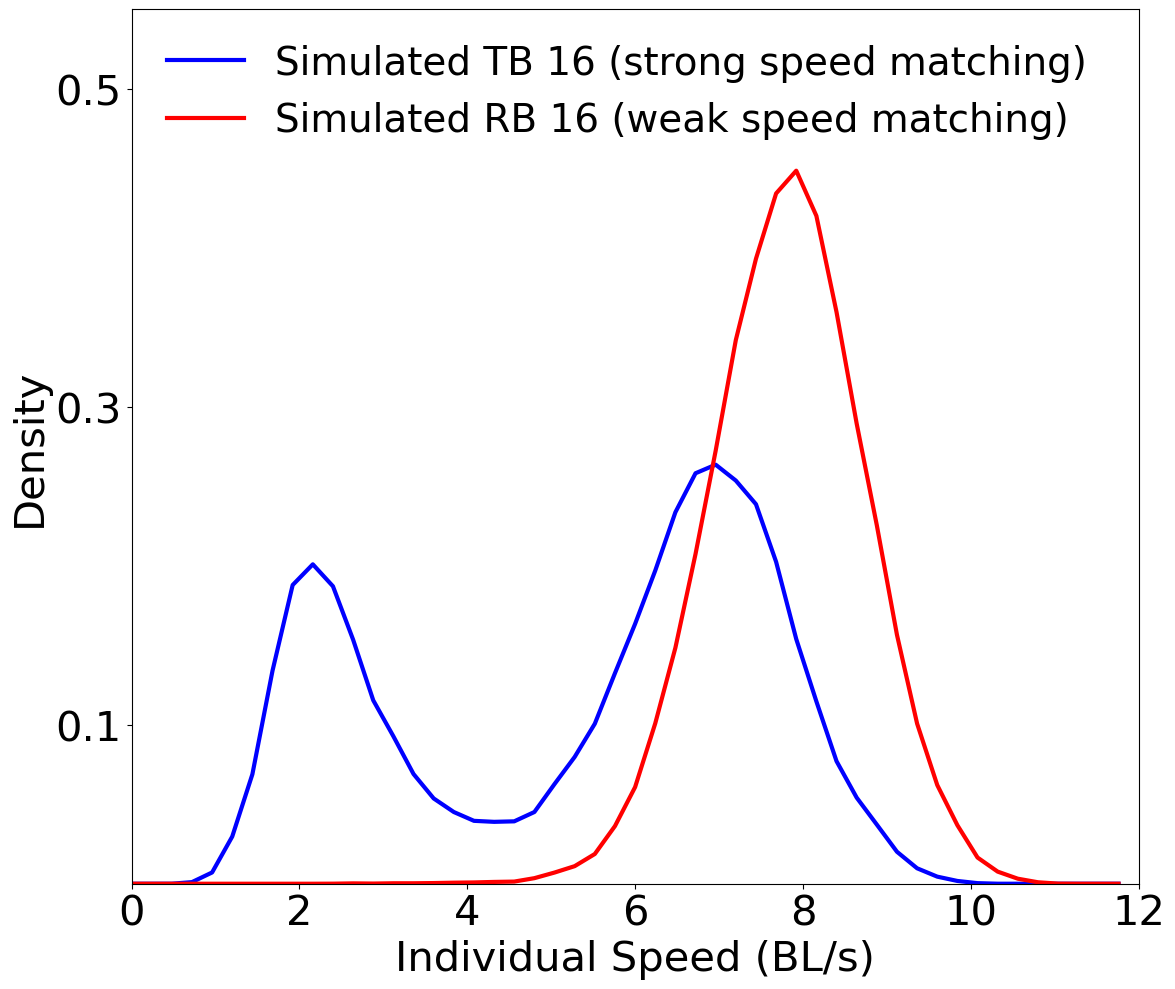

In [8]:
# Plotting individual speed distribution for single species simulations

# Import data
datar = np.load("model-with-sorting-rb_16_tb_0.npz")
datat = np.load("model-with-sorting-rb_0_tb_16.npz")
s_allr = datar['s_all']
s_allt = datat['s_all']

# Histogram
hist_rb16, bins = np.histogram(
    s_allr.ravel(), bins=50, density=True, range=(0, 12)
)
hist_tb16, _ = np.histogram(
    s_allt.ravel(), bins=50, density=True, range=(0, 12)
)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 10))

# Plot

ax.plot(bins[:-1], hist_tb16, label='Simulated TB 16 (strong speed matching)', color='blue',linewidth=3)
ax.plot(bins[:-1], hist_rb16, label='Simulated RB 16 (weak speed matching)', color='red' ,linewidth=3)

# Axis limits
ax.set_xlim(0, 12)
ax.set_ylim(0, 0.55)

# Ticks
ax.set_xticks(np.linspace(0, 12, 7))
ax.set_yticks(np.linspace(0.1, 0.5, 3))
ax.tick_params(axis='both', labelsize=30)

# Labels
ax.set_xlabel('Individual Speed (BL/s)', fontsize=30)
ax.set_ylabel('Density', fontsize=30)

# Legend
ax.legend(fontsize=28,  frameon=False, loc='upper left')

# Layout & save
fig.tight_layout()
fig.savefig('individual_speed_model_.png', bbox_inches='tight')
plt.show()

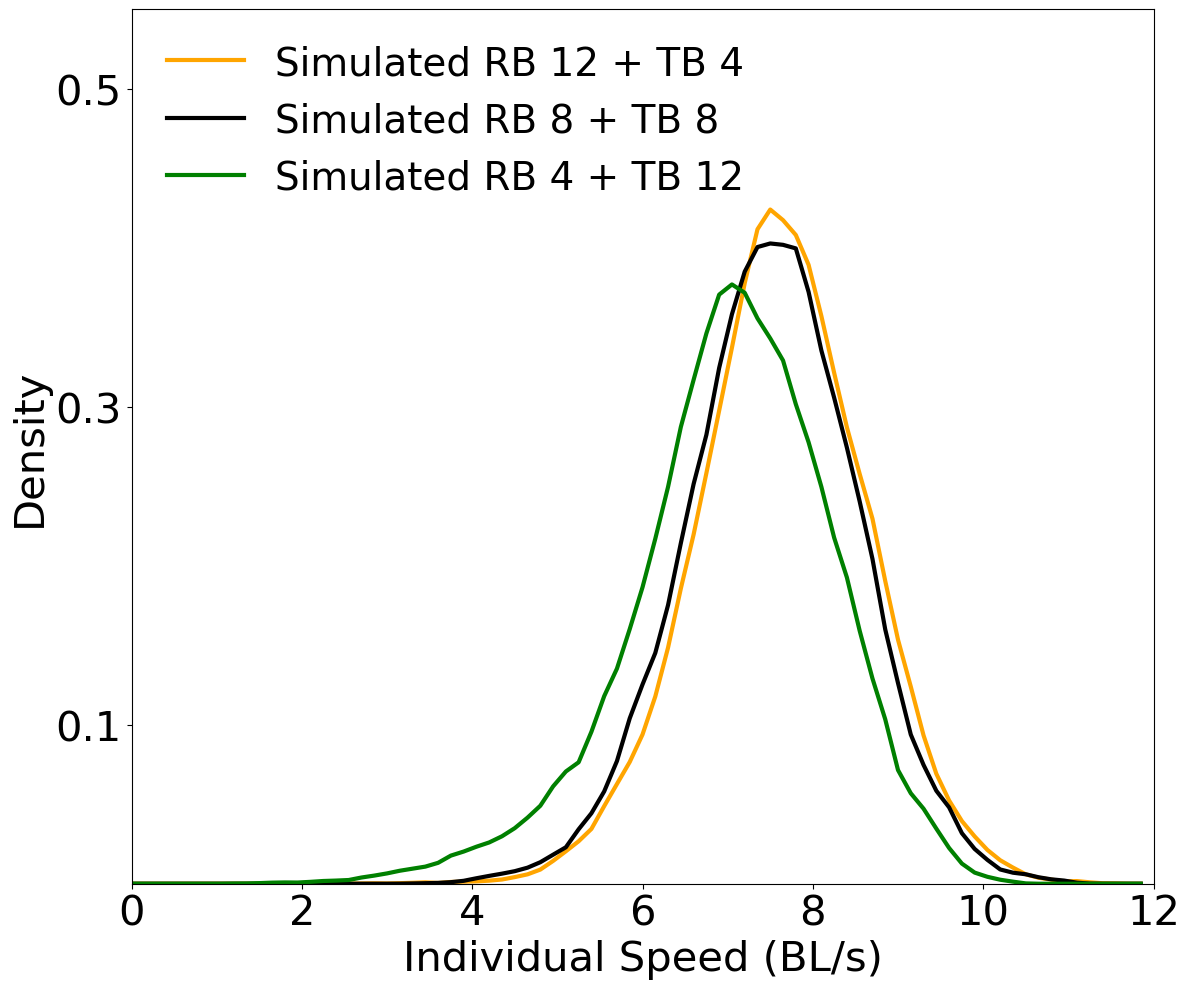

In [9]:
#Plotting individual speed distribution for mixed-species simulations

data1 = np.load("model-with-sorting-rb_4_tb_12.npz")
data2 = np.load("model-with-sorting-rb_8_tb_8.npz")
data3 = np.load("model-with-sorting-rb_12_tb_4.npz")

s_all1 = data1['s_all']
s_all2 = data2['s_all']
s_all3 = data3['s_all']

# Histogram
hist_rb4, bins = np.histogram(
    s_all1.ravel(), bins=80, density=True, range=(0, 12)
)
hist_rb8, _ = np.histogram(
    s_all2.ravel(), bins=80, density=True, range=(0, 12)
)

hist_rb12, _ = np.histogram(
    s_all3.ravel(), bins=80, density=True, range=(0, 12)
)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 10))

# Plot
ax.plot(bins[:-1], hist_rb12, label='Simulated RB 12 + TB 4', linewidth=3, color='orange')
ax.plot(bins[:-1], hist_rb8, label='Simulated RB 8 + TB 8', linewidth=3, color='black')
ax.plot(bins[:-1], hist_rb4, label='Simulated RB 4 + TB 12', linewidth=3, color='green')



# Axis limits
ax.set_xlim(0, 12)
ax.set_ylim(0, 0.55)

# Ticks
ax.set_xticks(np.linspace(0, 12, 7))
ax.set_yticks(np.linspace(0.1, 0.5, 3))
ax.tick_params(axis='both', labelsize=30)

# Labels
ax.set_xlabel('Individual Speed (BL/s)', fontsize=30)
ax.set_ylabel('Density', fontsize=30)

# Legend
ax.legend(fontsize=28,  frameon=False, loc='upper left')

# Layout & save
fig.tight_layout()
fig.savefig('individual_speed_mixed species model.png', bbox_inches='tight')
plt.show()

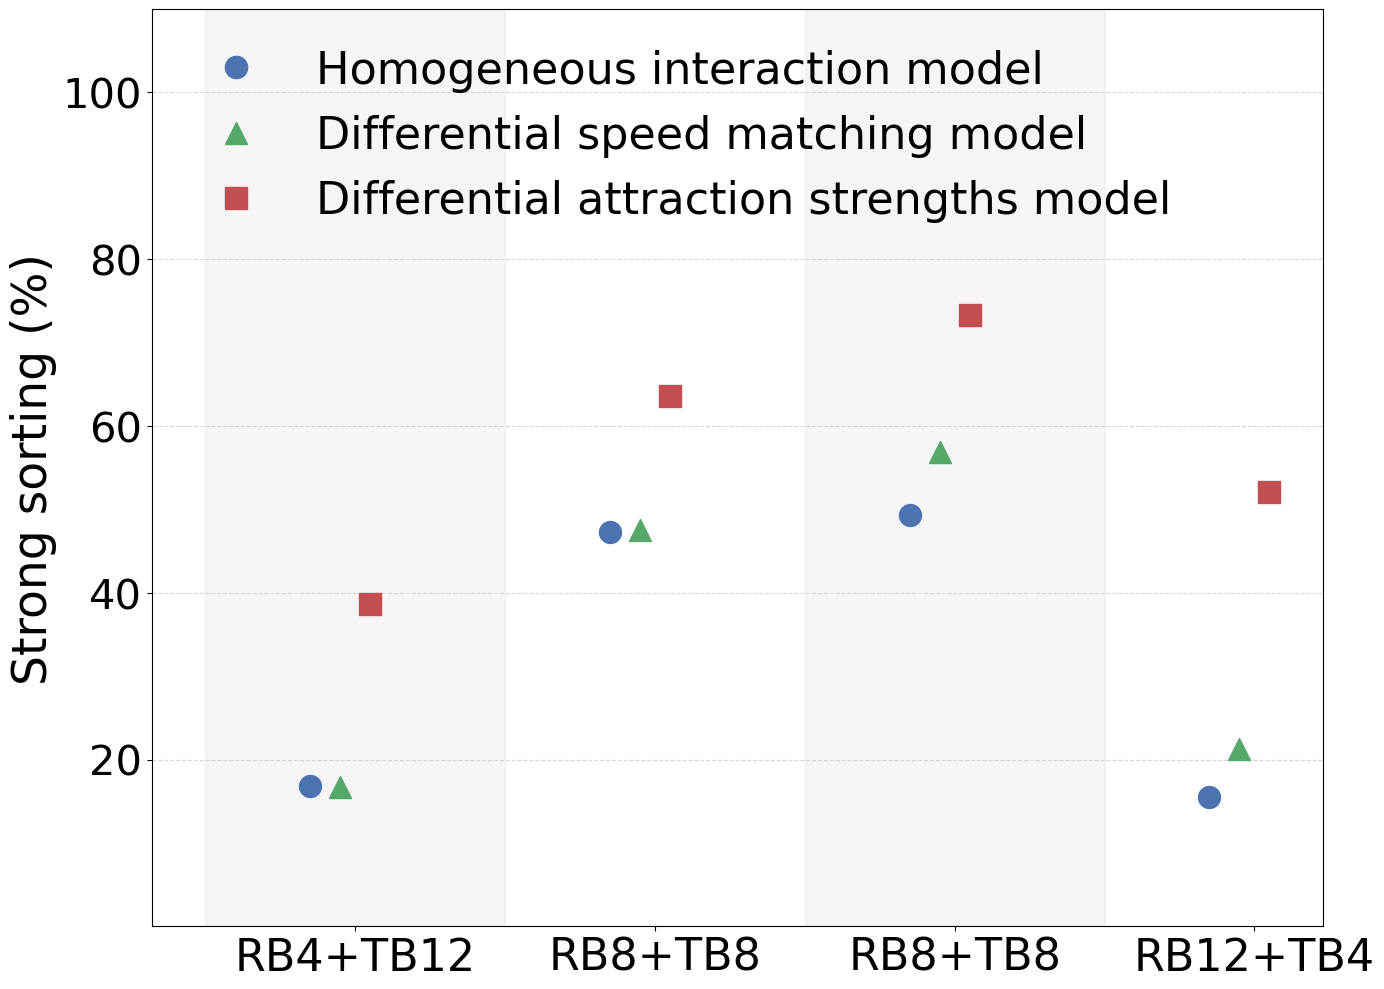

In [23]:
#Final Sorting plot

# Load simulation data 
sort   = np.load('model-with-sorting.npz')
nosort = np.load('model-wo-sorting.npz')
ident  = np.load('model-identical.npz')

# Labels
labels = ['RB4+TB12', 'RB8+TB8', 'RB8+TB8', 'RB12+TB4']
x = np.arange(len(labels))

# Mean function
def mean_only(data_list):
    return [np.mean(d) for d in data_list]

# Extract data
ident_data = [
    ident['sort_rb_4_12'],
    ident['sort_rb_8_8'],
    ident['sort_tb_8_8'],
    ident['sort_tb_12_4']
]

nosort_data = [
    nosort['sort_rb_4_12'],
    nosort['sort_rb_8_8'],
    nosort['sort_tb_8_8'],
    nosort['sort_tb_12_4']
]

sort_data = [
    sort['sort_rb_4_12'],
    sort['sort_rb_8_8'],
    sort['sort_tb_8_8'],
    sort['sort_tb_12_4']
]

ident_mean  = mean_only(ident_data)
nosort_mean = mean_only(nosort_data)
sort_mean   = mean_only(sort_data)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

offset = 0.10
size = 250

colors = {
    "ident":  "#4C72B0",  # muted blue
    "nosort": "#55A868",  # muted green
    "sort":   "#C44E52",  # muted red
}

# Scatter points
ax.scatter(
    x - 1.5*offset, ident_mean,
    s=size, marker='o',
    color=mcolors.to_rgba(colors["ident"], alpha=1),
    zorder=3
)

ax.scatter(
    x - 0.5*offset, nosort_mean,
    s=size, marker='^',
    color=mcolors.to_rgba(colors["nosort"], alpha=1),
    zorder=3
)

ax.scatter(
    x + 0.5*offset, sort_mean,
    s=size, marker='s',
    color=mcolors.to_rgba(colors["sort"], alpha=1),
    zorder=3
)

# Axes styling
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=32)
ax.set_ylabel('Strong sorting (%)', fontsize=34)
ax.set_ylim(0, 110)
ax.set_yticks(np.linspace(20, 100, 5))

ax.tick_params(axis='y', labelsize=30)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(False)

# Legend 
legend_elements = [
    Line2D(
        [0], [0], marker='o', linestyle='',
        color=mcolors.to_rgba(colors["ident"], alpha=1),
        markersize=16,
        label=r'Homogeneous interaction model'
    ),
    Line2D(
        [0], [0], marker='^', linestyle='',
        color=mcolors.to_rgba(colors["nosort"], alpha=1),
        markersize=16,
        label=r'Differential speed matching model'
    ),
    Line2D(
        [0], [0], marker='s', linestyle='',
        color=mcolors.to_rgba(colors["sort"], alpha=1),
        markersize=16,
        label=r'Differential attraction strengths model'
    ),
]

# background shading
for i in range(len(x)):
    if i % 2 == 0:
        ax.axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.08)
        
ax.legend(handles=legend_elements, frameon=False, fontsize=32, loc='upper left')

# Save
plt.tight_layout()
plt.savefig("sorting_model.png", dpi=300, bbox_inches="tight")
plt.show()


AttributeError: module 'matplotlib.pyplot' has no attribute 'set_xticks'

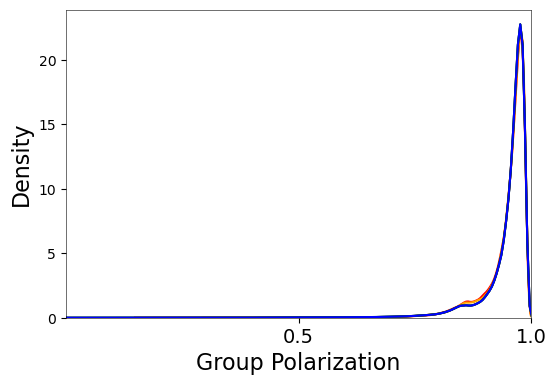

In [4]:
# Plotting group polarization for model simulations

# Import simulation data
data1 = np.load("model-with-soritng-rb_16_tb_0.npz")
data2 = np.load("model-with-soritng-rb_12_tb_4.npz")
data3 = np.load("model-with-soritng-rb_8_tb_8.npz")
data4 = np.load("model-with-soritng-rb_4_tb_12.npz")
data5 = np.load("model-with-soritng-rb_0_tb_16.npz")

m_all1 = data1['modm_all']
m_all2 = data2['modm_all']
m_all3 = data3['modm_all']
m_all4 = data3['modm_all']
m_all5 = data3['modm_all']

# Plot
plt.figure(figsize=(6,4))
sns.kdeplot(m_all1.ravel(), label='RB 16', color= 'Red')
sns.kdeplot(m_all2.ravel(), label='RB 12 + TB 4', color= 'Orange')
sns.kdeplot(m_all3.ravel(), label='RB 8 + TB 12', color= 'Black')
sns.kdeplot(m_all4.ravel(), label='RB 4 + TB 12', color= 'Green')
sns.kdeplot(m_all5.ravel(), label='TB 16', color= 'Blue')

plt.xlabel("Group Polarization", fontsize=16)
plt.ylabel("Density", fontsize=16)

# Increase tick label font size
plt.xticks(np.linspace(0.5, 1, 2), fontsize=14)  
#plt.yticks(np.linspace(0, 15, 4), fontsize=14)

plt.xlim(0,1)
for spine in plt.gca().spines.values():
    spine.set_linewidth(0.4)

# Ticks
plt.set_xticks(np.linspace(0, 1, 3))
plt.set_yticks(np.linspace(5, 20, 4))
plt.tick_params(axis='both', labelsize=18)

plt.legend(fontsize=14,  frameon=False, loc='upper left')
plt.tight_layout()

plt.savefig('polarization_model.png', dpi=300, bbox_inches='tight')  # Save with high resolution
plt.show()